# Day 2 Vocalization Table Generation
## Generating H5 Segment Files and vocSelTable with Spectrograms + MPS

This notebook processes Day 2 (Feb 27, 2019) zebra finch audio recordings into a structured
analysis table. It extracts individual vocalization segments from WAV files, computes spectrograms
and Modulation Power Spectra (MPS) using BioSound, and merges them with bird identity metadata
from soundsep2.

### Pipeline Overview
1. **Generate H5 files** — Slice WAV files into individual vocalization segments (12–4 PM only)
2. **Build vocSelTable** — Load H5 files, compute MPS, merge with metadata using `file.start_index`
3. **Split & Export** — Save as 3 pickle parts for memory-efficient loading
4. **Verify** — Confirm MPS computation and bird label match rates

### Notes
- **Time filter (12–4 PM)**: Only afternoon recordings are analyzed to match the Day 1 time window
- **Join key (`file.start_index`)**: The metadata CSV's `project.start_index` is a cumulative counter
  across all recordings (~237M for afternoon files), which doesn't match the file-level indices in
  H5 filenames. Using `file.start_index` gives a 100% match rate.
- **H5 folder cleaning**: The H5 folder may contain files from previous runs at other times of day.
  The pipeline filters by filename timestamp rather than trusting the folder contents.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import os
import pandas as pd
import glob
from scipy.io import wavfile
from soundsig.sound import BioSound
from joblib import Parallel, delayed
import warnings

%matplotlib inline

## Configuration

Set all file paths here. These should point to your local copies of:
- **raw_wav_folder**: Directory containing the original WAV recordings
- **h5_output_folder**: Where individual H5 segment files will be saved
- **csv_path**: The soundsep2 segment export CSV with bird labels and timing info
- **pickle_output_path**: Where the final vocSelTable pickle parts will be saved

In [2]:
# =============================================================================
# FILE PATHS: Remember to update these to match your local directory structure!
# =============================================================================

# Raw WAV recordings for Day 2
raw_wav_folder = '/Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/Feb 27, 2019'

# Output folder for individual H5 segment files
h5_output_folder = '/Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/Feb 27, 2019/h5filesSpectro_Day2'

# Soundsep2 metadata CSV (contains bird labels, timing, channel info)
csv_path = '/Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/export/segment_export.csv'

# Output path template for pickle parts
pickle_base_path = '/Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/vocSelTable_MPS_SpectroD2_part{}.pkl'

## Step 1: Generate H5 Segment Files from WAV Recordings

This cell reads each WAV file, looks up the segment boundaries from the soundsep2 CSV,
and saves each individual vocalization as a separate H5 file using BioSound.

**Time filter**: Only WAV files from 12 PM – 4 PM are processed. The recording hour
is extracted from the filename (e.g., `2019_02_27 12-01-00 Ch2.wav` → hour 12).

**Segment slicing**: Uses `file.start_index` and `file.stop_index` from the CSV to
slice the WAV signal. These are sample-level indices relative to the start of each
individual WAV file (not the project-level cumulative index).

**Output naming**: Each H5 file is named `{wav_name}_{file_start_index}.h5`, which
becomes the join key for matching with metadata later.

**Important**: If re-running, clear the H5 output folder first to avoid mixing
files from different runs with different parameters.

In [3]:
# =============================================================================
# STEP 1: GENERATE H5 SEGMENT FILES FROM WAV RECORDINGS
# =============================================================================

# Create output folder if it doesn't exist
if not os.path.exists(h5_output_folder):
    os.makedirs(h5_output_folder)

# Load segment metadata
print(f"Loading segment table from: {csv_path}")
df = pd.read_csv(csv_path)

# Determine which column contains the WAV filename
if 'file.name' in df.columns:
    group_col = 'file.name'
elif 'filename' in df.columns:
    group_col = 'filename'
else:
    group_col = 'source.name'

# Find available WAV files
os.chdir(raw_wav_folder)
available_wavs = set(glob.glob('*.wav'))
grouped = df.groupby(group_col)
total_processed = 0

for wav_name, group in grouped:
    base_name = os.path.basename(str(wav_name))

    # Skip WAVs that don't exist in the folder
    if base_name not in available_wavs:
        continue

    # TIME FILTER: Only process 12 PM – 4 PM recordings
    try:
        time_part = base_name.split(' ')[1]   # e.g., "12-01-00"
        hour = int(time_part.split('-')[0])    # e.g., 12
        if hour < 12 or hour >= 16:
            print(f"Skipping {base_name} (outside 12–4 PM window)")
            continue
    except Exception:
        pass  # If filename doesn't match expected format, process anyway

    print(f"Processing {base_name} ({len(group)} segments)...")

    # Read the full WAV file
    try:
        samp_rate, full_signal = wavfile.read(base_name)
    except Exception as e:
        print(f"  Error reading {base_name}: {e}")
        continue

    # If stereo, take the first channel
    if full_signal.ndim > 1:
        full_signal = full_signal[:, 0]

    # Process each segment in this WAV file
    for _, row in group.iterrows():
        try:
            # Use file-level indices (not project-level)
            t_start = int(row['file.start_index'])
            t_stop = int(row['file.stop_index'])

            # Bounds check
            if t_start < 0 or t_stop > len(full_signal):
                continue

            # Extract the audio segment
            sound_data = full_signal[t_start:t_stop].astype(np.float64)

            # Create BioSound object, compute spectrogram, and save
            myBioSound = BioSound(soundWave=sound_data, fs=samp_rate)
            myBioSound.spectroCalc(spec_sample_rate=1000, freq_spacing=50, max_freq=10000)

            # Save as H5 with file_start_index in the filename (this becomes the join key)
            h5_name = f"{os.path.splitext(base_name)[0]}_{t_start}.h5"
            h5_path = os.path.join(h5_output_folder, h5_name)
            myBioSound.saveh5(h5_path)
            total_processed += 1
        except Exception:
            continue

    print(f"  Saved so far: {total_processed}")

print(f"\nDone! Generated {total_processed} H5 segment files.")

Loading segment table from: /Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/export/segment_export.csv
Skipping 2019_02_27 09-01-00 Ch2.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-01-00 Ch4.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-01-00 Ch5.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-01-00 Ch6.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-01-00 Ch7.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-38-46 Ch2.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-38-46 Ch4.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-38-46 Ch5.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-38-46 Ch6.wav (outside 12–4 PM window)
Skipping 2019_02_27 09-38-46 Ch7.wav (outside 12–4 PM window)
Processing 2019_02_27 12-01-00 Ch2.wav (3762 segments)...
  Saved so far: 3759
Processing 2019_02_27 12-01-00 Ch4.wav (5195 segments)...
  Saved so far: 8948
Processing 2019_02_27 12-01-00 Ch5.wav (15544 segments)...
  Saved so far: 24476
Processing

## Step 2: Build vocSelTable with Spectrograms and MPS

This cell reads all H5 segment files from the output folder, computes the Modulation
Power Spectrum (MPS) for each using BioSound, and merges with the soundsep2 metadata
to get bird identity labels.

**Time filter**: H5 files are filtered by filename to include only 12–4 PM segments,
in case the folder contains files from previous runs.

**MPS computation**: `mpsCalc(window=0.05, Norm=True)` computes the 2D Fourier transform
of the spectrogram with a 50ms window and normalization. This captures the temporal and
spectral modulation structure of each call.

**Join key**: The `match_id` is constructed from `filename_clean + "_" + file.start_index`.
This matches the H5 filename format created in Step 1. We use `file.start_index` (the
sample position within the individual WAV file) rather than `project.start_index` (the
cumulative position across all recordings in the project), because the H5 filenames
contain file-level indices.

**Threading**: Uses `joblib` with the threading backend to parallelize H5 loading and
MPS computation. The threading backend avoids the memory errors that occur with process-based
parallelism due to numba/llvmlite serialization issues.

In [4]:
# =============================================================================
# STEP 2: BUILD VOCSELECTABLE WITH SPECTROGRAMS AND MPS
# =============================================================================

print(f"--- Building vocSelTable ---")
df_meta = pd.read_csv(csv_path)

# Clean filenames and build match IDs
# Extract just the filename without extension from the full path
df_meta['filename_clean'] = df_meta['file.name'].apply(
    lambda x: os.path.splitext(os.path.basename(str(x)))[0]
)

# Build match_id using file.start_index (NOT project.start_index)
# project.start_index is a cumulative counter across all recordings in the project,
# which reaches ~237 million for afternoon files — far exceeding individual WAV file lengths.
# file.start_index is the sample position within the individual WAV file,
# which matches the index embedded in the H5 filenames.
df_meta['match_id'] = (
    df_meta['filename_clean'] + "_" + df_meta['file.start_index'].astype(int).astype(str)
)

# Scan and filter H5 files
print(f"Scanning H5 files in {h5_output_folder}...")
os.chdir(h5_output_folder)
h5_files = glob.glob('*.h5')

# Filter to only include 12–4 PM files based on filename
# This catches any stale files from previous runs at other times
h5_files_filtered = []
for f in h5_files:
    try:
        hour = int(f.split(' ')[1].split('-')[0])
        if 12 <= hour < 16:
            h5_files_filtered.append(f)
    except:
        pass

print(f"Total H5 files in folder: {len(h5_files)}")
print(f"After 12–4 PM filter: {len(h5_files_filtered)}")


# Suppress BioSound MPS window size warnings globally.
# These fire for every short call (~50% of segments) and flood stdout,
# which significantly slows down I/O-bound parallel processing.
warnings.filterwarnings('ignore', message='.*mps.*window.*')

def process_h5_file(fname):
    """
    Load a single H5 segment file, compute its MPS, and return a data row.
    
    Returns a dict with:
      - 'spectro': the BioSound spectrogram (2D numpy array)
      - 'mps': the Modulation Power Spectrum (2D numpy array, or None if computation failed)
      - 'match_id': string key for joining with metadata CSV (format: "wavname_fileStartIndex")
    """
    try:
        myBioSound = BioSound()
        myBioSound.readh5(fname)

        # Compute MPS with warning suppression inside the worker thread.
        # window=0.05 sets a 50ms analysis window; Norm=True normalizes the output.
        # For very short calls, BioSound automatically reduces the window size
        # and emits a warning — we suppress these since the fallback behavior is fine.
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                myBioSound.mpsCalc(window=0.05, Norm=True)
                mps_data = myBioSound.mps
        except:
            mps_data = None

        # Build match_id from filename.
        # H5 files are named like "2019_02_27 12-01-00 Ch2_159383.h5"
        # We split at the last underscore to get "2019_02_27 12-01-00 Ch2" + "159383"
        # and recombine as "2019_02_27 12-01-00 Ch2_159383" to match the CSV's
        # filename_clean + "_" + file.start_index format.
        name_no_ext = os.path.splitext(fname)[0]
        if "_" in name_no_ext:
            split_idx = name_no_ext.rfind("_")
            file_part = name_no_ext[:split_idx]
            index_part = name_no_ext[split_idx + 1:]
            match_key = f"{file_part}_{index_part}"
        else:
            match_key = name_no_ext

        return {
            'spectro': myBioSound.spectro,
            'mps': mps_data,
            'match_id': match_key
        }
    except:
        return None

# --- Process all H5 files in batches with progress tracking ---
# Threading backend is used because process-based parallelism causes
# memory errors with numba/llvmlite (used internally by soundsig).
# Batching in groups of 5000 provides progress updates and keeps
# memory usage stable by not queuing all 66k tasks at once.
print(f"Processing {len(h5_files_filtered)} H5 files...")
batch_size = 5000
data_rows = []

for batch_start in range(0, len(h5_files_filtered), batch_size):
    batch = h5_files_filtered[batch_start:batch_start + batch_size]
    
    # Run this batch in parallel across all available CPU threads
    batch_results = Parallel(n_jobs=-1, backend='threading')(
        delayed(process_h5_file)(fname) for fname in batch
    )
    
    # Collect successful results (filter out None from failed files)
    data_rows.extend([r for r in batch_results if r is not None])
    
    # Progress update
    processed = min(batch_start + batch_size, len(h5_files_filtered))
    print(f"  {processed}/{len(h5_files_filtered)} done "
          f"({len(data_rows)} valid so far)")

print(f"Successfully processed {len(data_rows)} files.")

# Merge with metadata
print(f"Merging {len(data_rows)} audio segments with metadata...")
df_spectro = pd.DataFrame(data_rows)
full_df = pd.merge(df_spectro, df_meta, on='match_id', how='left')

# Rename columns for clarity
full_df.rename(columns={'source.name': 'Bird', 'tags': 'calltype'}, inplace=True)

# Keep only the columns needed for analysis
required_cols = ['Bird', 'file.start_index', 'calltype', 'spectro', 'mps', 'to', 'fo']
for col in required_cols:
    if col not in full_df.columns:
        full_df[col] = np.nan

vocSelTableSpectroD2 = full_df[required_cols].copy()

# Print summary
bird_matched = vocSelTableSpectroD2['Bird'].notna().sum()
total = len(vocSelTableSpectroD2)
print(f"\nRows with Bird label: {bird_matched}/{total} ({100*bird_matched/total:.1f}%)")
print(f"\nBird distribution:")
print(vocSelTableSpectroD2['Bird'].value_counts(dropna=False))
print(f"\nDataFrame structure:")
print(vocSelTableSpectroD2.info())

--- Building vocSelTable ---
Scanning H5 files in /Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/Feb 27, 2019/h5filesSpectro_Day2...
Total H5 files in folder: 98624
After 12–4 PM filter: 66418
Processing 66418 H5 files...
Warning in mps: Requested MPS window size is greater than spectrogram temporal extent.
mps will be calculate with windows of 47 points or 0.04689342403628118 s
Warning in mps: Requested MPS window size is greater than spectrogram temporal extent.
mps will be calculate with windows of 45 points or 0.044897959183673466 s
Warning in mps: Requested MPS window size is greater than spectrogram temporal extent.
mps will be calculate with windows of 39 points or 0.03891156462585034 s
Warning in mps: Requested MPS window size is greater than spectrogram temporal extent.
mps will be calculate with windows of 35 points or 0.03492063492063492 s
Warning in mps: Requested MPS window size is greater than spectrogram temporal extent.
mps will be calculat

## Step 3: Split and Export as Pickle Parts

The full table is too large for a single pickle file, so we split it into 3 roughly
equal parts. The analysis pipeline loads and concatenates all 3 parts when needed.

In [6]:
print(type(vocSelTableSpectroD2))

<class 'pandas.DataFrame'>


In [8]:
# =============================================================================
# STEP 3: SPLIT AND EXPORT AS PICKLE PARTS
# =============================================================================

df_parts = [vocSelTableSpectroD2.iloc[i::3].reset_index(drop=True) for i in range(3)]
for i, df_part in enumerate(df_parts):
    save_path = pickle_base_path.format(i + 1)
    df_part.to_pickle(save_path)
    print(f"Saved: {save_path} ({len(df_part)} rows)")

print(f"\nTotal rows saved: {sum(len(p) for p in df_parts)}")

Saved: /Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/vocSelTable_MPS_SpectroD2_part1.pkl (22140 rows)
Saved: /Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/vocSelTable_MPS_SpectroD2_part2.pkl (22139 rows)
Saved: /Users/lynnc/OneDrive/Desktop/finch/BioSound/soundsep2/data/projectPepe/DAY2/vocSelTable_MPS_SpectroD2_part3.pkl (22139 rows)

Total rows saved: 66418


## Step 4: Verification

Quick sanity checks to confirm:
1. Spectrograms and MPS arrays are valid numpy arrays with expected dimensions
2. Bird labels matched correctly
3. MPS values are non-trivial (not all zeros)

VERIFICATION: vocSelTable Quality Check

Total rows: 66418
Valid spectrograms: 66418/66418
Sample spectrogram shape: (196, 101)
Valid MPS: 66418/66418
Sample MPS shape: (196, 51)

Bird label match rate: 66411/66418 (100.0%)

H5 files by recording hour (in folder):
  09:00 -> 32,206 files *** OUTSIDE 12-4 PM ***
  12:00 -> 33,995 files
  15:00 -> 32,423 files


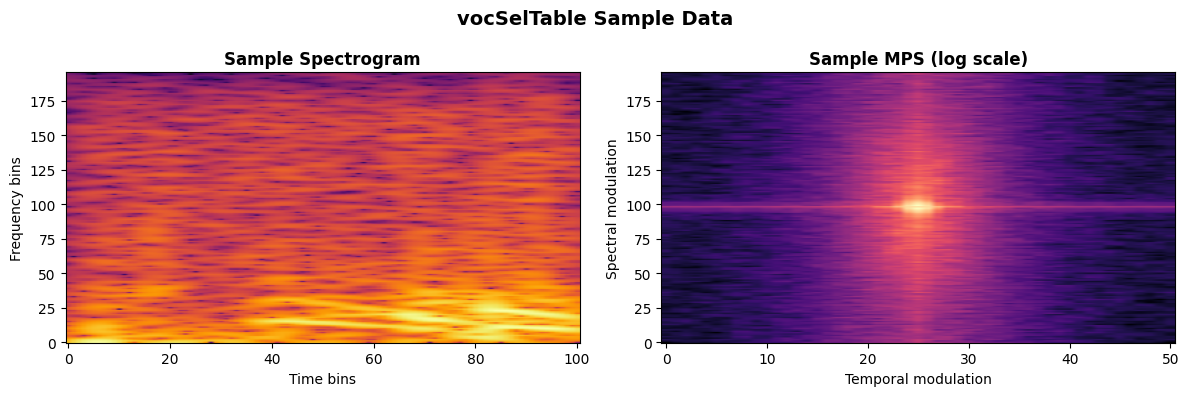


Verification complete.


In [ ]:
# =============================================================================
# STEP 4: VERIFICATION
# =============================================================================
import matplotlib.pyplot as plt

print(f"{'='*60}")
print("VERIFICATION: vocSelTable Quality Check")
print(f"{'='*60}")

# Check data types and shapes
print(f"\nTotal rows: {len(vocSelTableSpectroD2)}")

# Check spectrograms
valid_spectro = sum(1 for s in vocSelTableSpectroD2['spectro']
                    if isinstance(s, np.ndarray) and s.ndim == 2)
print(f"Valid spectrograms: {valid_spectro}/{len(vocSelTableSpectroD2)}")

if valid_spectro > 0:
    sample_spec = vocSelTableSpectroD2['spectro'].dropna().iloc[0]
    print(f"Sample spectrogram shape: {sample_spec.shape}")

# Check MPS
valid_mps = sum(1 for m in vocSelTableSpectroD2['mps']
                if isinstance(m, np.ndarray) and m.ndim == 2)
print(f"Valid MPS: {valid_mps}/{len(vocSelTableSpectroD2)}")

if valid_mps > 0:
    sample_mps = vocSelTableSpectroD2['mps'].dropna().iloc[0]
    print(f"Sample MPS shape: {sample_mps.shape}")

# Check bird labels
print(f"\nBird label match rate: {vocSelTableSpectroD2['Bird'].notna().sum()}/{len(vocSelTableSpectroD2)} "
      f"({100*vocSelTableSpectroD2['Bird'].notna().sum()/len(vocSelTableSpectroD2):.1f}%)")

# Check time window (from H5 filenames)
print(f"\nH5 files by recording hour (in folder):")
os.chdir(h5_output_folder)
all_h5 = glob.glob('*.h5')
hour_counts = {}
for f in all_h5:
    try:
        hour = f.split(' ')[1].split('-')[0]
        hour_counts[hour] = hour_counts.get(hour, 0) + 1
    except:
        hour_counts['unknown'] = hour_counts.get('unknown', 0) + 1

for hour in sorted(hour_counts.keys()):
    flag = " *** OUTSIDE 12-4 PM ***" if hour.isdigit() and (int(hour) < 12 or int(hour) >= 16) else ""
    print(f"  {hour}:00 -> {hour_counts[hour]:,} files{flag}")

# Plot a sample spectrogram and MPS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(sample_spec, origin='lower', aspect='auto', cmap='inferno')
ax1.set_title('Sample Spectrogram', fontweight='bold')
ax1.set_xlabel('Time bins'); ax1.set_ylabel('Frequency bins')

if valid_mps > 0:
    log_mps = np.log10(np.abs(sample_mps) + 1e-10)
    ax2.imshow(log_mps, origin='lower', aspect='auto', cmap='magma')
    ax2.set_title('Sample MPS (log scale)', fontweight='bold')
    ax2.set_xlabel('Temporal modulation'); ax2.set_ylabel('Spectral modulation')

plt.suptitle('vocSelTable Sample Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Verification complete.")
print(f"{'='*60}")